In [ ]:
# Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

In [ ]:
# Ejercicio 1: BOOSTING CON ADABOOST

# 1. Cargar dataset
path='/content/winequality-red.csv'
vinos = pd.read_csv(path, sep=';')

In [ ]:
# 2. Transformar la variable quality en binaria (>=6 = "Bueno", <6 = "Malo")
vinos["quality_bin"] = vinos["quality"].apply(lambda q: "Bueno" if q >= 6 else "Malo")

# 3. División en train/test
X = vinos.drop(columns=["quality", "quality_bin"])
y = vinos["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# 4. Entrenar modelo AdaBoost con árboles débiles (CART con pocas ramas)
base_tree = DecisionTreeClassifier(max_depth=2, random_state=123)
boost_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=50,       # mfinal = 50
    random_state=123
)
for lr in [0.05, 0.1, 0.2, 0.3]:
    boost_model_lr = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=50,
        learning_rate=lr,
        random_state=123
    )
    # accuracy promedio en 5 folds
    scores = cross_val_score(boost_model_lr, X_train, y_train, cv=5, scoring="accuracy")
    mean_acc = scores.mean()
    mean_err = 1 - mean_acc
    print(f"learning_rate={lr}, error promedio en CV: {mean_err:.4f}")

learning_rate=0.05, error promedio en CV: 0.2752
learning_rate=0.1, error promedio en CV: 0.2658
learning_rate=0.2, error promedio en CV: 0.2635
learning_rate=0.3, error promedio en CV: 0.2650


In [ ]:
# 6. Entrenar modelo final con el mejor learning_rate
best_lr = 0.2
boost_model_final = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=50,
    learning_rate=best_lr,
    random_state=123
)
boost_model_final.fit(X_train, y_train)

# 5. Predicciones
y_pred = boost_model_final.predict(X_test)

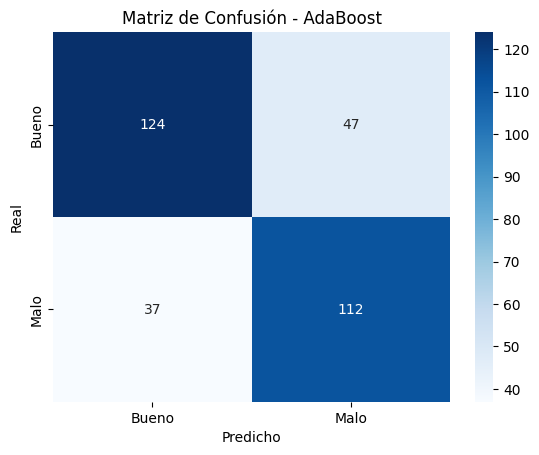

Accuracy: 0.7375


In [ ]:
# 6. Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=["Bueno", "Malo"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bueno", "Malo"], yticklabels=["Bueno", "Malo"])
plt.title("Matriz de Confusión - AdaBoost")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# 7. Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

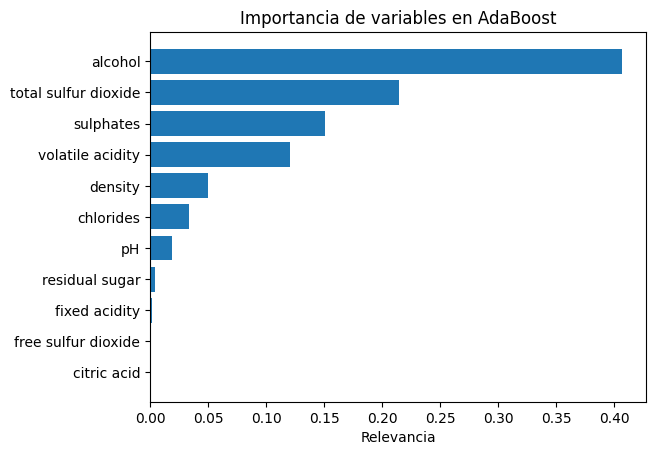

In [ ]:
# 8. Importancia de variables
importances = boost_model_final.feature_importances_
feat_imp = pd.DataFrame({"Variable": X.columns, "Importancia": importances})
feat_imp = feat_imp.sort_values("Importancia", ascending=True)

plt.barh(feat_imp["Variable"], feat_imp["Importancia"])
plt.title("Importancia de variables en AdaBoost")
plt.xlabel("Relevancia")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


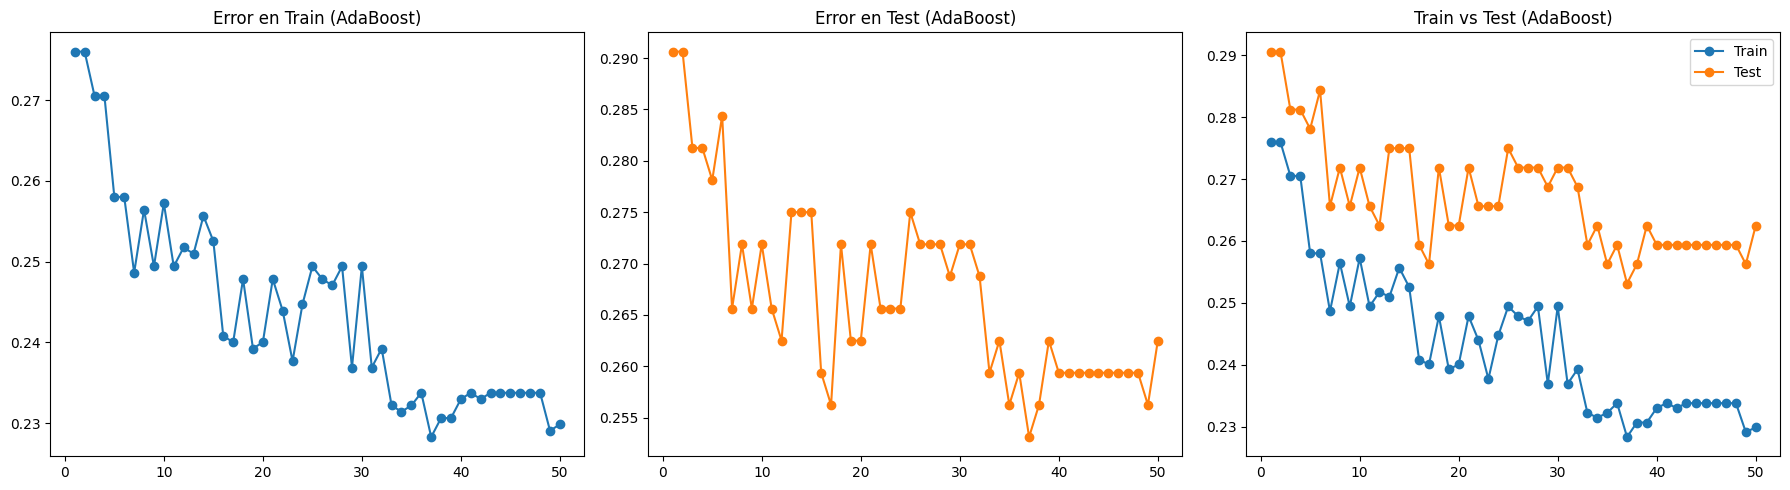

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Calcular errores en train y test con list comprehensions
errors_train = [1 - accuracy_score(y_train, y_pred)
                for y_pred in boost_model_final.staged_predict(X_train)]
errors_test  = [1 - accuracy_score(y_test, y_pred)
                for y_pred in boost_model_final.staged_predict(X_test)]

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
iters = range(1, len(errors_train)+1)

# Gráfico 1: solo train
axes[0].plot(iters, errors_train, marker="o")
axes[0].set_title("Error en Train (AdaBoost)")

# Gráfico 2: solo test
axes[1].plot(iters, errors_test, marker="o", color="C1")
axes[1].set_title("Error en Test (AdaBoost)")

# Gráfico 3: train vs test superpuestos
axes[2].plot(iters, errors_train, label="Train", marker="o")
axes[2].plot(iters, errors_test, label="Test", marker="o")
axes[2].set_title("Train vs Test (AdaBoost)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Ejercicio 1: BOOSTING CON XGBOOST

# 1. Transformar la variable target en binaria
vinos["quality_bin"] = (vinos["quality"] >= 6).astype(int)

# 2. Separar variables predictoras y target
X = vinos.drop(columns=["quality", "quality_bin"])
y = vinos["quality_bin"]

# 3. División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# 4. Estandarizar
scaler = StandardScaler()
X_train_est = scaler.fit_transform(X_train)
X_test_est = scaler.transform(X_test)

# 5. Crear matrices para XGBoost
# Crear matrices para XGBoost con nombres de columnas correctos
dtrain = xgb.DMatrix(data=X_train_est, label=y_train, feature_names=X.columns.tolist())
dtest  = xgb.DMatrix(data=X_test_est, label=y_test, feature_names=X.columns.tolist())


# 6. Validación cruzada probando distintas tasas de aprendizaje
params = {
    "objective": "binary:logistic",
    "max_depth": 2,
    "eval_metric": "error",
    "seed": 123
}

for eta in [0.05, 0.1, 0.2, 0.3]:
    params["eta"] = eta
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=50,
        nfold=5,
        metrics="error",
        seed=123,
        stratified=True
    )
    print(f"eta={eta}, mínimo error promedio: {cv_results['test-error-mean'].min()}")


eta=0.05, mínimo error promedio: 0.25566789215686275
eta=0.1, mínimo error promedio: 0.24472120098039216
eta=0.2, mínimo error promedio: 0.23689950980392158
eta=0.3, mínimo error promedio: 0.2407996323529412


In [ ]:
# 7. Entrenar modelo final con el último eta probado
params["eta"] = 0.2
modelo = xgb.train(params, dtrain, num_boost_round=50)

# 8. Predicciones en test
pred = modelo.predict(dtest)
pred_class = (pred > 0.5).astype(int)

# 9. Evaluación del modelo
acc = accuracy_score(y_test, pred_class)
cm = confusion_matrix(y_test, pred_class)

print("Accuracy en test:", acc)

Accuracy en test: 0.76875


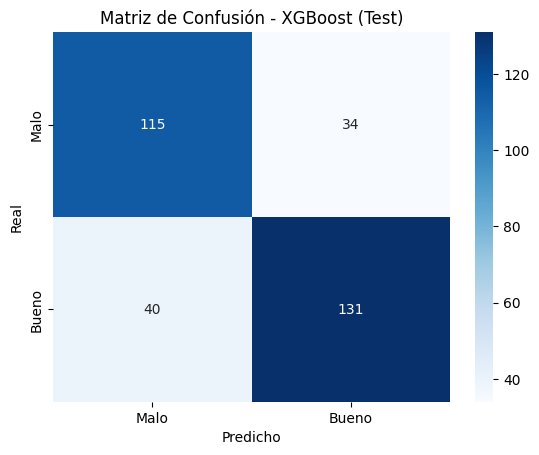

In [ ]:
#10. Visualizacion de la Matriz de Confusión
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malo","Bueno"], yticklabels=["Malo","Bueno"])
plt.title("Matriz de Confusión - XGBoost (Test)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

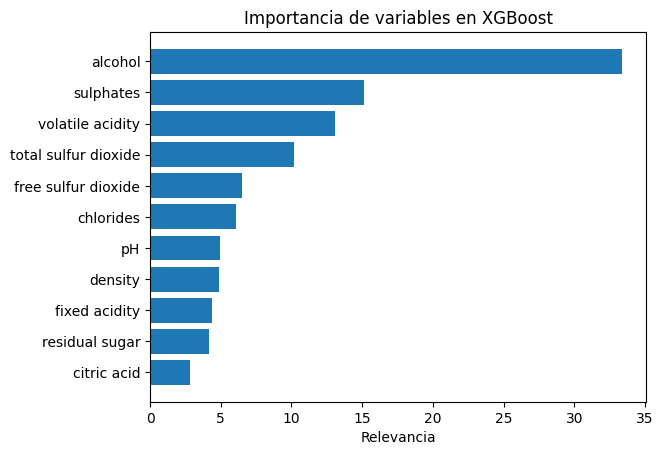

In [ ]:
# 9. Importancia de variables
imp = modelo.get_score(importance_type="gain")
imp_df = pd.DataFrame({"Variable": list(imp.keys()), "Importancia": list(imp.values())})
imp_df = imp_df.sort_values("Importancia", ascending=True)

plt.barh(imp_df["Variable"], imp_df["Importancia"])
plt.title("Importancia de variables en XGBoost")
plt.xlabel("Relevancia")
plt.show()

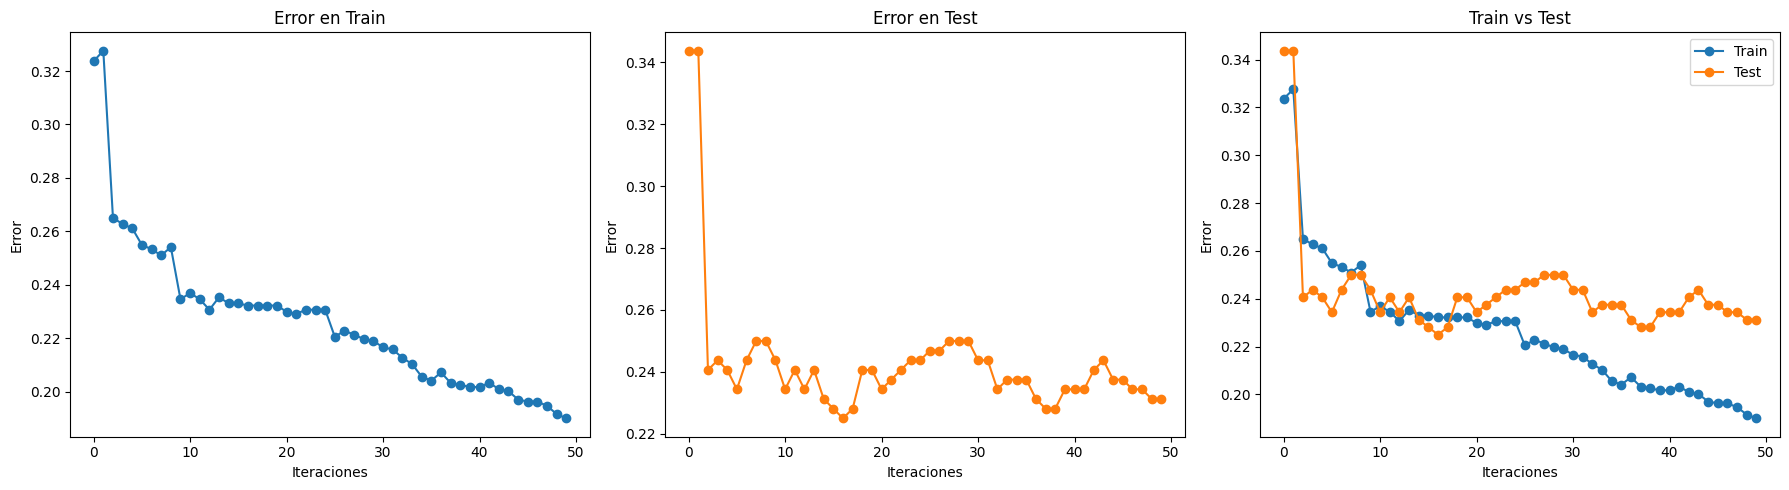

In [ ]:
# 10. Evolución del error vs número de iteraciones
evals_result = {}
modelo = xgb.train(
    params,
    dtrain,
    num_boost_round=50,
    evals=[(dtrain, "train"), (dtest, "test")],
    evals_result=evals_result,
    verbose_eval=False
)

# Crear figura con 3 subplots en una fila
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfico 1: solo train ---
axes[0].plot(evals_result["train"]["error"], marker="o")
axes[0].set_title("Error en Train")
axes[0].set_xlabel("Iteraciones")
axes[0].set_ylabel("Error")

# --- Gráfico 2: solo test ---
axes[1].plot(evals_result["test"]["error"], marker="o", color= "C1")
axes[1].set_title("Error en Test")
axes[1].set_xlabel("Iteraciones")
axes[1].set_ylabel("Error")

# --- Gráfico 3: train vs test superpuestos ---
axes[2].plot(evals_result["train"]["error"], label="Train", marker="o")
axes[2].plot(evals_result["test"]["error"], label="Test", marker="o")
axes[2].set_title("Train vs Test")
axes[2].set_xlabel("Iteraciones")
axes[2].set_ylabel("Error")
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
#Ejercicio 02: ANÁLISIS DE COMPONENTES PRINCIPALES

#Carga de dataset
nutricion = pd.read_csv("/content/tabla_nutricional.csv", sep=";")

In [ ]:
nutricion = nutricion.fillna(0) # Remplazo los valores NULL por 0
nutricion.isnull().sum() # Verificio que no haya valores NULL
print(f"Dataset cargado con {nutricion.shape[0]} alimentos y {nutricion.shape[1]} variables.")

Dataset cargado con 53 alimentos y 13 variables.


In [ ]:
nutricion["Na (gr)"] = nutricion["Na (mg)"] / 1000
nutricion["Ca (gr)"] = nutricion["Ca (mg)"] / 1000
nutricion["Fe (gr)"] = nutricion["Fe (mg)"] / 1000

nutricion = nutricion.drop(columns=['Na (mg)', 'Ca (mg)', 'Fe (mg)']) #Elimino las columnas que estaban en mg

In [ ]:
#Seleccion de valores numericos
X = nutricion.select_dtypes(include=[np.number])
# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convertir de nuevo a DataFrame para mantener los nombres de las columnas
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [ ]:
#B) Aplicación del PCA

#Inicializar y aplicar el PCA
pca = PCA(n_components=None) # n_components=None significa que sklearn conservará todos los componentes (min(n_muestras, n_características)).
pca.fit(X_scaled)

#Transformar los datos al nuevo espacio de componentes principales
scores_nutricion = pca.transform(X_scaled)
scores_df = pd.DataFrame(scores_nutricion, index=X.index)
scores_df.columns = [f'CP{i+1}' for i in range(scores_df.shape[1])]

In [ ]:
#C) Análisis y Resultados del PCA

#Varianza Explicada por cada Componente
explained_variance_ratio = pca.explained_variance_ratio_
num_components = len(explained_variance_ratio)

variance_df = pd.DataFrame({
    'CP': [f'CP{i+1}' for i in range(num_components)],
    'Varianza Explicada (%)': explained_variance_ratio * 100,
    'Varianza Acumulada (%)': explained_variance_ratio.cumsum() * 100
})

print("\nAnálisis de Varianza Explicada por Componente:")
print(variance_df.head(12).to_markdown(index=False, floatfmt=".2f"))
print(f"\nLa Varianza Acumulada con CP1 y CP2 es: {variance_df['Varianza Acumulada (%)'].iloc[1]:.2f}%")
print("---------------------------------------------------")

#Desglose de las Cargas (Loadings/Rotación)
# Las cargas muestran la contribución de cada variable original a cada CP.
loadings = pd.DataFrame(pca.components_.T, columns=variance_df['CP'], index=X.columns)

print("\nLoadings (Cargas) - Contribución de Variables a los CP:")
# Mostramos la contribución a los dos primeros CP (los que usaremos para el Biplot)
print(loadings[['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12']].sort_values(by='CP1', ascending=False).to_markdown(floatfmt=".3f"))
print("------------------------------------------------------------------------------------------------------------------------------------")


Análisis de Varianza Explicada por Componente:
| CP   |   Varianza Explicada (%) |   Varianza Acumulada (%) |
|:-----|-------------------------:|-------------------------:|
| CP1  |                    22.46 |                    22.46 |
| CP2  |                    15.40 |                    37.86 |
| CP3  |                    12.96 |                    50.82 |
| CP4  |                    11.19 |                    62.01 |
| CP5  |                     8.73 |                    70.74 |
| CP6  |                     8.20 |                    78.94 |
| CP7  |                     7.94 |                    86.88 |
| CP8  |                     6.96 |                    93.84 |
| CP9  |                     3.46 |                    97.30 |
| CP10 |                     1.72 |                    99.02 |
| CP11 |                     0.62 |                    99.64 |
| CP12 |                     0.36 |                   100.00 |

La Varianza Acumulada con CP1 y CP2 es: 37.86%
----------------------

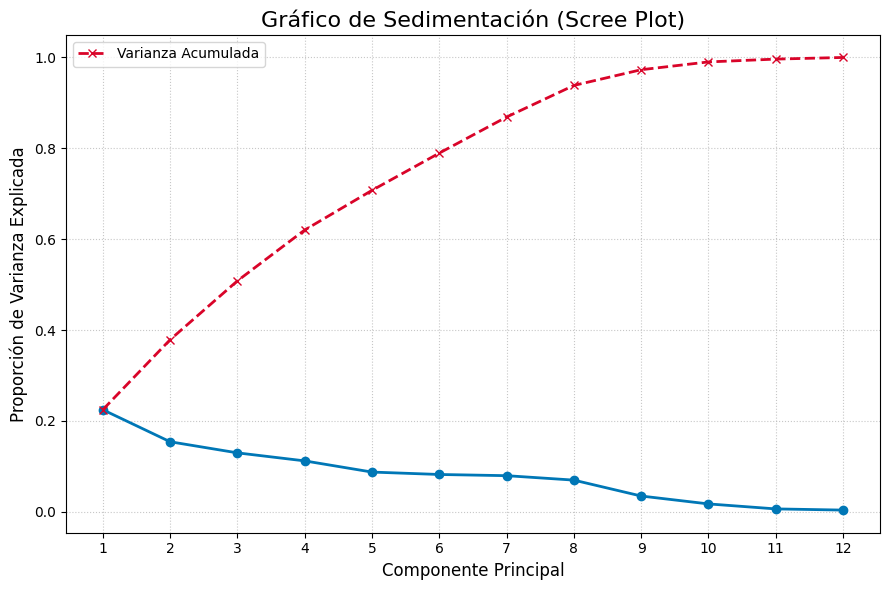

In [ ]:
# 2. Gráfico de Sedimentación (Scree Plot)
# Para decidir cuántos componentes retener
plt.figure(figsize=(9, 6))
plt.plot(range(1, num_components + 1), explained_variance_ratio,
         marker='o', linestyle='-', color='#0077b6', linewidth=2)
plt.plot(range(1, num_components + 1), explained_variance_ratio.cumsum(),
         marker='x', linestyle='--', color='#d90429', linewidth=2, label='Varianza Acumulada')

plt.title('Gráfico de Sedimentación (Scree Plot)', fontsize=16)
plt.xlabel('Componente Principal', fontsize=12)
plt.ylabel('Proporción de Varianza Explicada', fontsize=12)
plt.xticks(range(1, num_components + 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


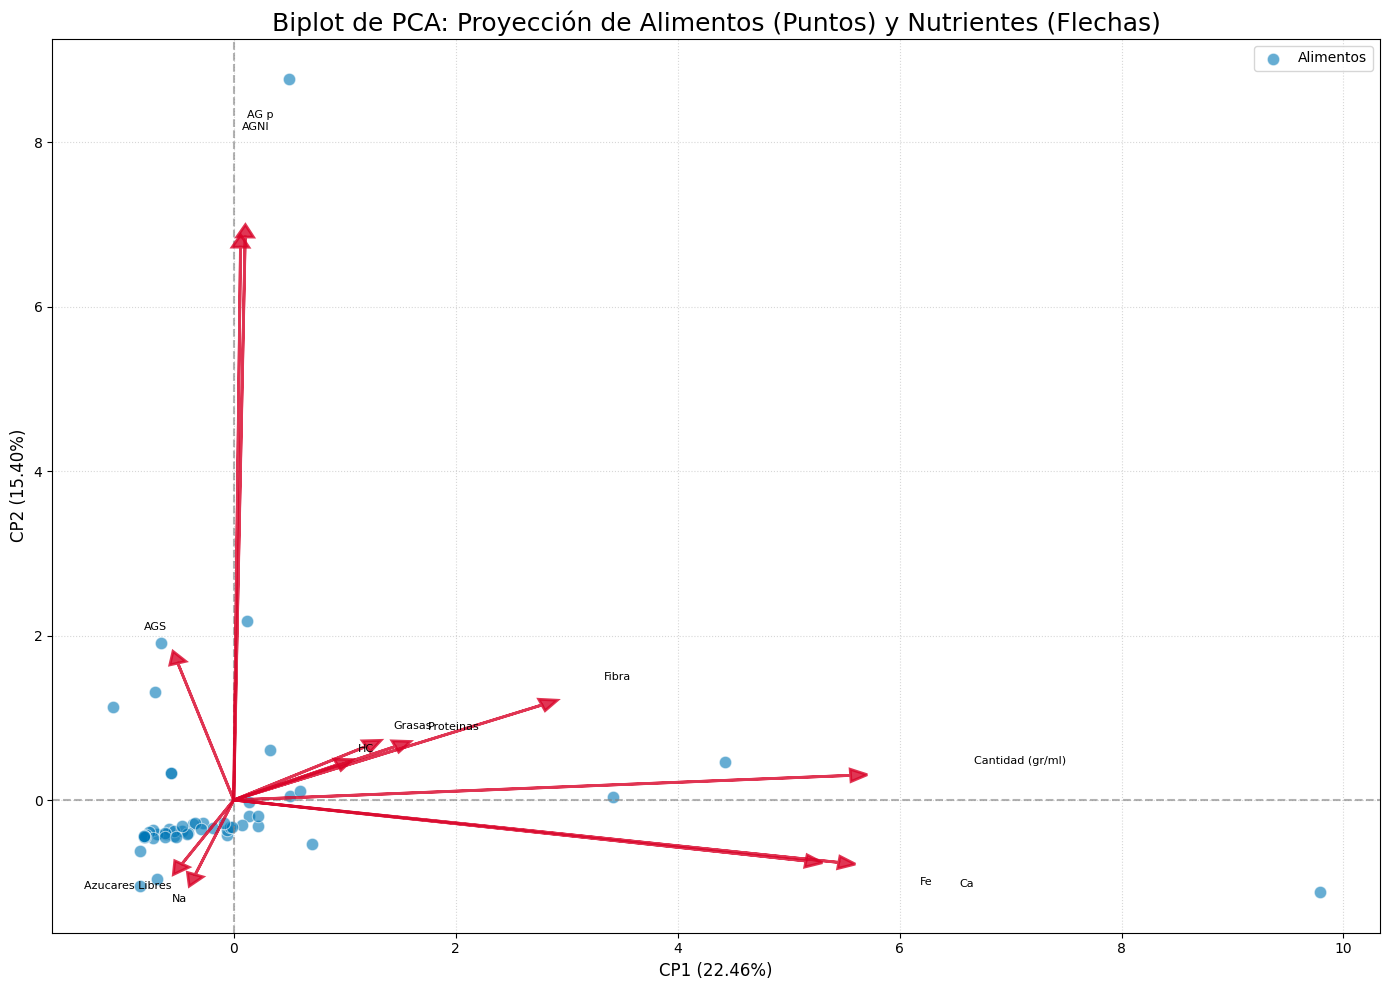

In [ ]:
CP1 = 'CP1'
CP2 = 'CP2'
plt.figure(figsize=(14, 10))
scale_factor_arrows = scores_df[['CP1', CP2]].abs().max().max() / loadings[['CP1', CP2]].abs().max().max() * 0.7

# Dibujar los puntos (Scores) - Los alimentos
sns.scatterplot(x=scores_df[CP1], y=scores_df[CP2], s=80, color='#0077b6', alpha=0.6, label='Alimentos', zorder=1)

# Dibujar las flechas (Loadings) y etiquetarlas
offset_factor = 1.20
vertical_offset_from_line = 0.05

for i in range(loadings.shape[0]):
    x_arrow = loadings.iloc[i, 0] * scale_factor_arrows
    y_arrow = loadings.iloc[i, 1] * scale_factor_arrows

    # Preparamos la etiqueta, sin saltos de línea para que sea horizontal
    label = loadings.index[i].replace(' (gr)', '')

    # Calculamos la posición del texto
    x_text = x_arrow * offset_factor
    y_text = y_arrow * offset_factor

    # Definimos la alineación horizontal: 'left' si está a la derecha, 'right' si está a la izquierda
    ha_alignment = 'left' if x_arrow >= 0 else 'right'

    if y_arrow >= 0:
        y_text += vertical_offset_from_line # Pequeño empuje hacia arriba
        va_alignment = 'bottom' # Alinea la parte inferior del texto a y_text
    else:
        y_text -= vertical_offset_from_line # Pequeño empuje hacia abajo
        va_alignment = 'top' # Alinea la parte superior del texto a y_text


    plt.arrow(0, 0, x_arrow, y_arrow,
              color='#d90429', alpha=0.8, head_width=0.15, head_length=0.15, linewidth=2, zorder=5)

    # Añadir la etiqueta de la variable
    plt.text(x_text, y_text, label,
             color='black',       # Color negro
             fontsize=8,          # Tamaño de fuente reducido
             ha=ha_alignment,     # Alineación horizontal ajustada
             va=va_alignment,
             fontweight='normal',
             rotation=0,          # Gira el texto a 0 grados (paralelo al eje X)
             zorder=10)           # Asegura que el texto este por encima de la flecha
# Configuración del gráfico
percent_cp1 = explained_variance_ratio[0]*100
percent_cp2 = explained_variance_ratio[1]*100
plt.title('Biplot de PCA: Proyección de Alimentos (Puntos) y Nutrientes (Flechas)', fontsize=18)
plt.xlabel(f"{CP1} ({percent_cp1:.2f}%)", fontsize=12)
plt.ylabel(f"{CP2} ({percent_cp2:.2f}%)", fontsize=12)
plt.axhline(0, color='grey', linestyle='--', alpha=0.6)
plt.axvline(0, color='grey', linestyle='--', alpha=0.6)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()